In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import os
from matplotlib.ticker import FormatStrFormatter, FuncFormatter


In [2]:
pae_features = pd.read_csv('../data/M5K_pae_features.csv')
rmsd_features = pd.read_csv('../data/M5K_rmsd_features.csv')

In [3]:
def map_rmsd_type(label):
    [seed1, sample1, seed2, sample2] = label.split("_")
    if seed1==seed2:
        return 'Intra-seed'
    return 'Inter-seed'
rmsd_features['RMSD'] = rmsd_features.seed_sample.apply(map_rmsd_type)

/tmp/ipykernel_2957621/1012440657.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1,11))
/tmp/ipykernel_2957621/1012440657.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1,11))
/tmp/ipykernel_2957621/1012440657.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1,11))


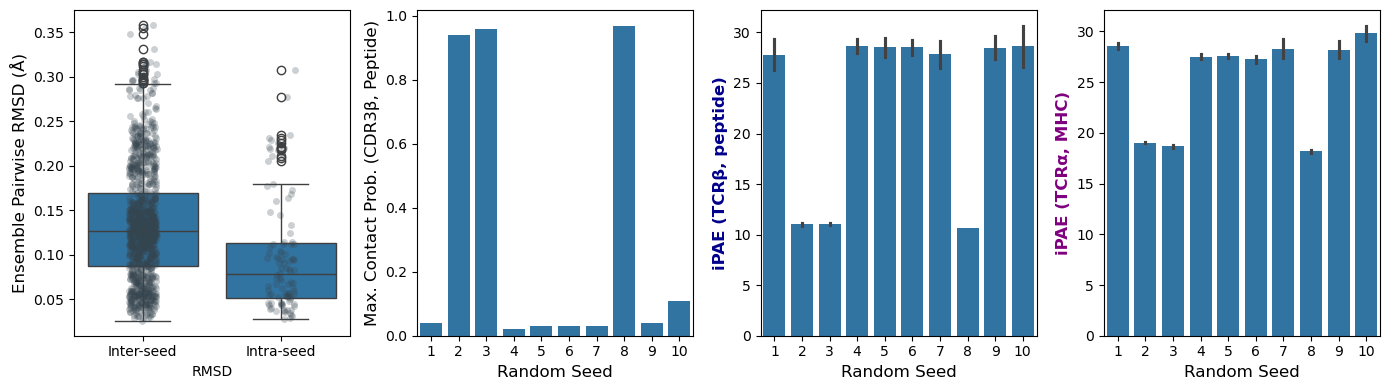

In [4]:
fig, axes = plt.subplots(figsize=(14,4),ncols=4,nrows=1)

fontsize=12

sns.stripplot(rmsd_features, y='Ensemble Pairwise RMSD (Å)',ax=axes[0],x='RMSD',color='#36454F',alpha=.25)
sns.boxplot(rmsd_features, y='Ensemble Pairwise RMSD (Å)',ax=axes[0],x='RMSD',color='tab:blue')
axes[0].set_ylabel('Ensemble Pairwise RMSD (Å)',fontsize=fontsize,)

feature = 'max_contact_probs_cdr3b_P'
sns.barplot(pae_features,x='af3_seed',y=feature,ax=axes[1],errorbar='sd',color='tab:blue')
axes[1].set_ylabel('Max. Contact Prob. (CDR3β, Peptide)',fontsize=fontsize,)


feature = 'avg_pae_interaction_B_P'
sns.barplot(pae_features,x='af3_seed',y=feature,ax=axes[2],errorbar='sd',color='tab:blue')

axes[2].set_ylabel('iPAE (TCRβ, peptide)',fontsize=fontsize,color='#00008B',fontweight='bold')


feature = 'avg_pae_interaction_A_M'
axes[3].set_ylabel('iPAE (TCRα, MHC)',fontsize=fontsize,color='purple',fontweight='bold')
sns.barplot(pae_features,x='af3_seed',y=feature,ax=axes[3],errorbar='sd',color='tab:blue')




for ax in axes[1:]:
    ax.set_xticklabels(range(1,11))
    ax.set_xlabel('Random Seed',fontsize=fontsize)


fig.tight_layout()
